## 1. Models

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Linear Regression

In [2]:
from models import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [3]:
x, y = make_regression(n_samples=1000, n_features=5, noise=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [4]:
model = LinearRegression(lr=1e-2, ridge_coef=0.001, lasso_coef=0.001)
model

LinearRegression(
    max_iter=1000,
    lr=0.01,
    tol=1e-06,
    early_stopping_patience=10,
    ridge_coef=0.001,
    lasso_coef=0.001,
    trained=False
)

In [5]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)
resids = y_test - y_pred

R-squared: 0.9989233718350967


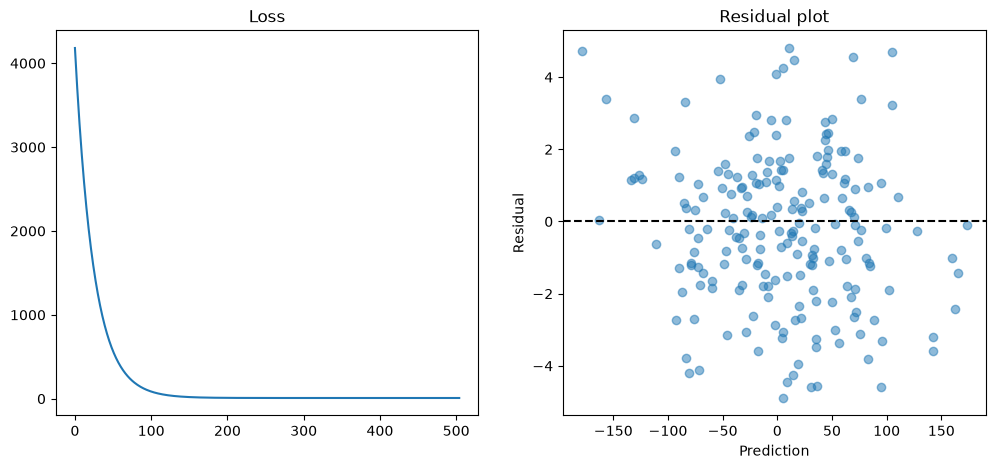

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, resids, alpha=0.5)
plt.title('Residual plot')
plt.xlabel('Prediction')
plt.ylabel('Residual')
plt.axhline(0, c='k', ls='--')
print("R-squared:", r2_score(y_test, y_pred))

### Logistic Regression

In [7]:
from models import LogisticRegression
from metrics import accuracy, precision, recall, f1
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [8]:
x, y = make_classification(n_samples=1000, n_features=5, n_classes=2, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [9]:
model = LogisticRegression(lr=1e-1, threshold=0.5)
model

LogisticRegression(
    max_iter=1000,
    lr=0.1,
    tol=1e-06,
    early_stopping_patience=10,
    threshold=0.5,
    trained=False
)

In [10]:
losses = model.train(x_train, y_train)
y_pred = model(x_test)

Accuracy: 0.865
F1: 0.8646121309776538


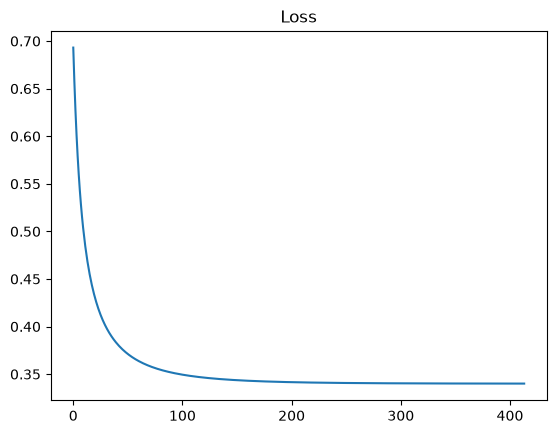

In [11]:
plt.plot(losses)
plt.title('Loss')
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

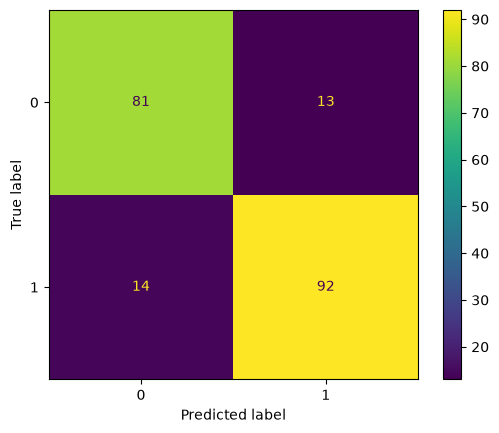

In [12]:
conf_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot();

### KNN Classifier

In [13]:
from models import KNNClassifier

In [14]:
model = KNNClassifier(n_neighbors=5)
model

KNNClassifier(
    n_neighbors=5,
    trained=False
)

In [15]:
model.train(x_train, y_train)
y_pred = model(x_test)

In [16]:
print("Accuracy:", accuracy(y_test, y_pred))
print("F1:", f1(y_test, y_pred))

Accuracy: 0.87
F1: 0.8713432330614983


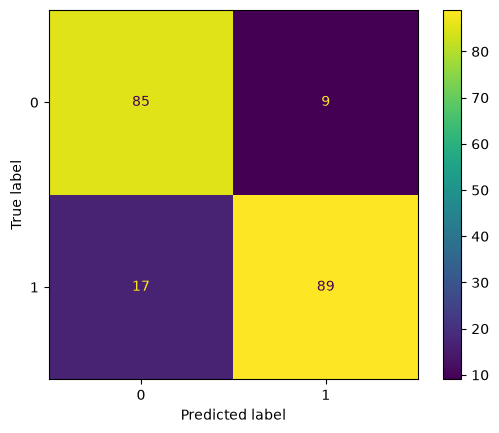

In [17]:
conf_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot();

In [18]:
# multiclass
x, y = make_classification(n_samples=1000, n_informative=5, n_redundant=0, n_features=5, n_classes=10, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [19]:
model.train(x_train, y_train)
y_pred = model(x_test)

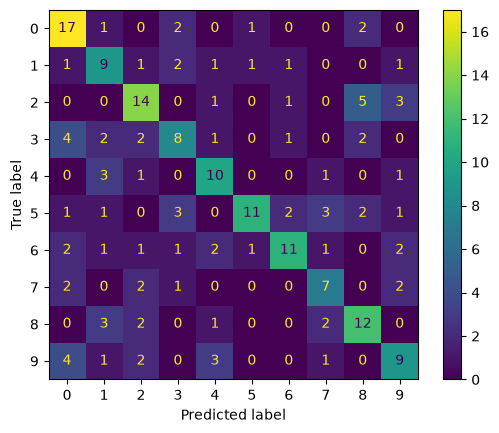

In [20]:
conf_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(conf_mat)
disp.plot();